In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
)

In [35]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [36]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

In [37]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names  = train_data.target_names

In [38]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classes :", len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes : 20


In [39]:
vectorizer = CountVectorizer(
    stop_words= "english",
    min_df=2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [40]:
X_train = vectorizer.fit_transform(X_train_text)
X_test =vectorizer.transform(X_test_text)

In [41]:
print("Training feature matrix: ",X_train.shape)
print("Testing feature matrix: ",X_test.shape)

Training feature matrix:  (11314, 39115)
Testing feature matrix:  (7532, 39115)


In [42]:
mnb = MultinomialNB()

mnb.fit(
    X_train,
    y_train
)
y_pred_mnb = mnb.predict(X_test)

In [43]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [44]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
)

In [77]:
def evaluate(model_name, y_true, y_pred):
    print("\n", "-" * 40)
    print(model_name)
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall   :", recall_score( y_true, y_pred, average="weighted"))
    print("F1 Score :", f1_score( y_true, y_pred, average="weighted"))

In [78]:
evaluate("Multinomial Naive Bayes", y_test, y_pred_mnb)
evaluate("Bernoulli Naive Bayes", y_test, y_pred_bnb)


 ----------------------------------------
Multinomial Naive Bayes
----------------------------------------
Accuracy : 0.6510886882634095
Precision: 0.642532222238185
Recall   : 0.6510886882634095
F1 Score : 0.6296441343359875

 ----------------------------------------
Bernoulli Naive Bayes
----------------------------------------
Accuracy : 0.4851301115241636
Precision: 0.6270343160004399
Recall   : 0.4851301115241636
F1 Score : 0.4808387927958853


In [79]:
results_nb = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
models_nb = [("Multinomial NB", y_pred_mnb), ("Bernoulli NB", y_pred_bnb)]
for name, pred in models_nb:
    results_nb.loc[len(results_nb)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score( y_test, pred, average="weighted"),
        recall_score(y_test, pred, average="weighted"),
        f1_score(y_test, pred, average="weighted")
    ]
print(results_nb)

            Model  Accuracy  Precision    Recall  F1 Score
0  Multinomial NB  0.651089   0.642532  0.651089  0.629644
1    Bernoulli NB  0.485130   0.627034  0.485130  0.480839


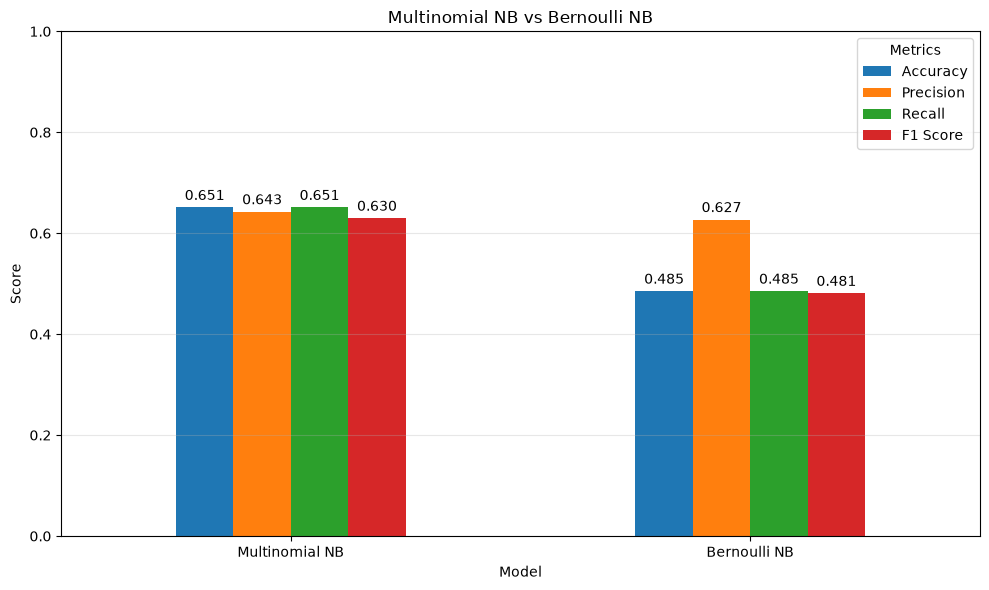

In [83]:
ax = results_nb.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Multinomial NB vs Bernoulli NB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()